# 10 · Capstone: an evidence-based shift handoff

**Mission:** combine outbreak burden, access disruption, and uncertainty into a reviewable exercise briefing. Allow 60 minutes. Prerequisites: Labs 04–09.

**Run:** choose the Python (Pyodide) kernel in JupyterLite, then Run → Run All Cells. First use downloads Matplotlib. All training data are **SYNTHETIC** unless explicitly labeled LIVE. Downloads appear below and in `exports/`; the browser filesystem is separate from your computer. Each lab runs independently.

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("matplotlib")
import json, math
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from worldview_lab import (load, export, map_layer, chart_style, haversine_km,
    wilson_interval, shortest_times, freshness, normalize_quakes,
    validate_geojson, brief_request, validate_brief)
chart_style()

## A multi-criteria exercise

An EOC asks which fictional districts deserve further review. Compare normalized outbreak burden with access time. Weighted scores are a **preference model**, not a validated medical priority or resource allocation rule. Explore how choices change the result; do not hide weights inside an AI narrative.

In [2]:
districts=load('districts.geojson');network=load('network.json');facilities=load('facilities.geojson')
open_nodes=[network['facility_nodes'][f['id']] for f in facilities['features'] if f['properties']['open']]
times=[shortest_times(network,node,True) for node in open_nodes]
rows=[dict(f['properties'],travel_minutes=min(t[f['id']] for t in times)) for f in districts['features']]
assert all(math.isfinite(r['travel_minutes']) for r in rows), 'Review disconnected districts separately'
def rank(weight):
    max_rate=max(r['rate_per_100k'] for r in rows);max_time=max(r['travel_minutes'] for r in rows) or 1
    return sorted([dict(r,score=weight*r['rate_per_100k']/max_rate+(1-weight)*r['travel_minutes']/max_time) for r in rows],key=lambda r:r['score'],reverse=True)
WEIGHT=.6
ranking=rank(WEIGHT)
display([{k:r[k] for k in ['id','rate_per_100k','travel_minutes','score']} for r in ranking[:5]])

[{'id': 'D07', 'rate_per_100k': 600.0, 'travel_minutes': 23, 'score': 1.0},
 {'id': 'D03',
  'rate_per_100k': 320.0,
  'travel_minutes': 20,
  'score': 0.6678260869565218},
 {'id': 'D09',
  'rate_per_100k': 300.0,
  'travel_minutes': 21,
  'score': 0.6652173913043478},
 {'id': 'D05',
  'rate_per_100k': 500.0,
  'travel_minutes': 9,
  'score': 0.6565217391304348},
 {'id': 'D04',
  'rate_per_100k': 133.33333333333334,
  'travel_minutes': 20,
  'score': 0.48115942028985503}]

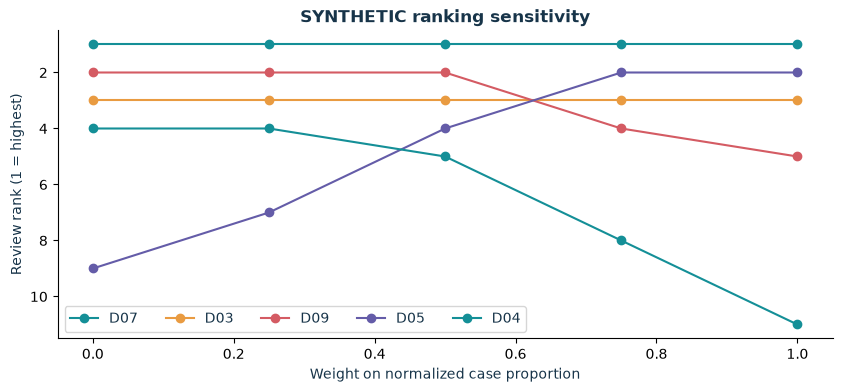

In [3]:
weights=[0,.25,.5,.75,1]
fig,ax=plt.subplots()
for district in [r['id'] for r in ranking[:5]]:
    positions=[[r['id'] for r in rank(w)].index(district)+1 for w in weights]
    ax.plot(weights,positions,'o-',label=district)
ax.invert_yaxis();ax.set(xlabel='Weight on normalized case proportion',ylabel='Review rank (1 = highest)',title='SYNTHETIC ranking sensitivity');ax.legend(ncol=5);plt.show()

In [4]:
bundle={'classification':'SYNTHETIC EXERCISE','scenario_clock':'2026-09-14T12:00:00Z',
 'evidence':[{'id':'CAP-01','metric':'review_ranking','burden_weight':WEIGHT,'rows':[{k:r[k] for k in ['id','rate_per_100k','travel_minutes','score']} for r in ranking]},
             {'id':'CAP-02','metric':'top_district_by_weight','rows':[{'weight':w,'district':rank(w)[0]['id']} for w in weights]}],
 'limitations':['Preference-weighted score, not a validated priority','Synthetic cases and network','Centroid and reporting biases','No capacity allocation or real-time verification']}
export('capstone-evidence.json',bundle)
export('capstone-astra-request.json',brief_request(bundle))

WindowsPath('exports/capstone-astra-request.json')

## Deliverables and review rubric

Submit a 2D map, a 3D screenshot with height definition, an epidemic curve, a weight-sensitivity chart, the evidence JSON, and a 150-word handoff. Use Astra optionally to draft or critique the handoff, preserving evidence IDs and uncertainties.

| Criterion | Points | Evidence |
|---|---:|---|
| Reproducible calculations | 3 | Fresh-kernel run, parameter values, units |
| Honest cartography | 2 | Legend, time window, synthetic label, height definition |
| Uncertainty and equity | 2 | Reporting, centroid, threshold, and weighting sensitivity |
| AI accountability | 2 | Prompt/evidence, reviewed citations, rejected unsupported claims |
| Actionable handoff | 1 | Verification question and named review role |

**Checkpoint:** the top district may change with the weight. Report this dependence rather than presenting one ranking as an objective truth. No score authorizes diagnosis, patient triage, or dispatch.

**Stretch:** adapt the workflow to a public aggregate dataset. Document license, time period, denominator, geography, missingness, and source before replacing the synthetic fixtures. Keep small-count disclosure and local governance requirements under domain review.

## Sources and attribution

Methods build on the preceding labs. See [CDC descriptive epidemiology](https://www.cdc.gov/field-epi-manual/php/chapters/describing-epi-data.html), [WHO EOC framework](https://www.who.int/publications/i/item/framework-for-a-public-health-emergency-operations-centre), and [Astra documentation](https://developers.openai.com/api/docs/models/gpt-6-astra).

World View inspiration: [Kevin (Khoa) To, MIT](https://github.com/kevtoe/worldview). Original lab code, figures, and synthetic fixtures: JupyterLite WorldView contributors, MIT. See the [book references](https://jltobias.github.io/JupyterLite-WorldView/book/references.html) and repository notices for dependency and service terms.